In [1]:
import os
import copy
import csv
import json
from datetime import datetime
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import rasterio
from rasterio.transform import xy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import geopandas as gpd
from shapely.geometry import Point

import wandb

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False

set_seed(42)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)


In [3]:
# pip install wandb

# Early stopping class

In [4]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0.001):
        self.patience     = patience
        self.delta        = delta
        self.counter      = 0
        self.best_score   = None
        self.best_weights = None
        self.early_stop   = False

    def __call__(self, score, model):
        """score is a loss/error -- lower is better."""
        if self.best_score is None or score < self.best_score - self.delta:
            self.best_score   = score
            self.best_weights = copy.deepcopy(model.state_dict())
            self.counter      = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


# Loss Functions

In [5]:
# class QuantileLoss(nn.Module):
#     def __init__(self, quantile=0.9):
#         super().__init__()
#         self.quantile = quantile

#     def forward(self, pred, target):
#         error = target - pred
#         return torch.max(self.quantile * error, (self.quantile - 1) * error).mean()

In [6]:
class WeibullWeightedMSELoss(nn.Module):
    def __init__(self, kappa=28.0, alpha=2.75, eps=1e-6):
        super().__init__()
        self.kappa = kappa
        self.alpha = alpha
        self.eps = eps

    def forward(self, preds, targets):
        k, a = self.kappa, self.alpha
        pdf = (k/a) * ((targets/a)**(k-1)) * torch.exp(-(targets/a)**k)
        weights = 1.0 / (pdf + self.eps)
        weights = weights / weights.mean()
        return (weights * (preds - targets)**2).mean()

In [7]:
class WeightedMSELoss(nn.Module):
    """MSE loss with linear weights based on target value.
    Pixels with higher CISI values receive proportionally higher weight,
    forcing the model to focus on city pixels without a custom distribution shape.
    weight = 1 + scale * target  (base weight 1 for all pixels, extra for high CISI)
    """
    def __init__(self, scale=5.0):
        super().__init__()
        self.scale = scale

    def forward(self, preds, targets):
        weights = 1.0 + self.scale * targets
        weights = weights / weights.mean()
        return (weights * (preds - targets) ** 2).mean()


In [8]:
# Weibull loss weight visualization
# import numpy as np
# import matplotlib.pyplot as plt

# eps = 1e-6
# cisi = np.linspace(0.001, 1.0, 500)

# Configurations to compare
# configs = [
#     {'kappa': 5,  'alpha': 2.75, 'label': 'kappa=5,  alpha=2.75'},
#     {'kappa': 15, 'alpha': 2.75, 'label': 'kappa=15, alpha=2.75'},
#     {'kappa': 28, 'alpha': 2.75, 'label': 'kappa=28, alpha=2.75 (default)'},
#     {'kappa': 45, 'alpha': 2.75, 'label': 'kappa=45, alpha=2.75'},
#     {'kappa': 28, 'alpha': 1.5,  'label': 'kappa=28, alpha=1.5'},
#     {'kappa': 28, 'alpha': 5.0,  'label': 'kappa=28, alpha=5.0'},
# ]

# fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# for cfg in configs:
#     k, a = cfg['kappa'], cfg['alpha']
#     pdf     = (k / a) * ((cisi / a) ** (k - 1)) * np.exp(-(cisi / a) ** k)
#     weights = 1.0 / (pdf + eps)
#     weights = weights / weights.mean()
#     ls = '-' if cfg['alpha'] == 2.75 else '--'
#     axes[0].plot(cisi, pdf,     label=cfg['label'], linestyle=ls)
#     axes[1].plot(cisi, weights, label=cfg['label'], linestyle=ls)

# axes[0].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='city threshold (0.15)')
# axes[1].axvline(0.15, color='grey', linestyle=':', linewidth=1, label='city threshold (0.15)')
# axes[1].axhline(1.0,  color='black', linestyle=':', linewidth=0.8, alpha=0.5, label='weight=1 (neutral)')

# axes[0].set_title('Weibull PDF')
# axes[0].set_xlabel('CISI value')
# axes[0].set_ylabel('Probability density')
# axes[0].legend(fontsize=8)

# axes[1].set_title('Loss weights (1 / PDF)  --  higher = model penalized more')
# axes[1].set_xlabel('CISI value')
# axes[1].set_ylabel('Normalized weight')
# axes[1].set_ylim(0, 15)
# axes[1].legend(fontsize=8)

# plt.tight_layout()
# plt.savefig('weibull_loss_weights.png', dpi=150, bbox_inches='tight')
# plt.show()


In [9]:
# class WeightedMSELoss(nn.Module):
#     def __init__(self, threshold=0.2, factor=25):
#         super().__init__()
#         self.threshold = threshold
#         self.factor = factor

#     def forward(self, predictions, targets):
#         weights = torch.where(
#             targets > self.threshold,
#             torch.ones_like(targets) * self.factor,
#             torch.ones_like(targets)
#         )
#         return (weights * (predictions - targets) ** 2).mean()

In [10]:
# class AsymmetricMSELoss(nn.Module):
#     def __init__(self, under_penalty=5.0):
#         super().__init__()
#         self.under_penalty = under_penalty
    
#     def forward(self, pred, target):
#         error = pred - target
#         loss = torch.where(error < 0,
#                           self.under_penalty * error ** 2,  # Under: 5× penalty
#                           error ** 2)                        # Over: 1× penalty
#         return loss.mean()

In [11]:
# class ContinuousWeightedMSELoss(nn.Module):
#     def __init__(self, base=1.0, scale=20.0):
#         super().__init__()
#         self.base = base
#         self.scale = scale

#     def forward(self, preds, targets):
#         weights = self.base + self.scale * targets
#         return (weights * (preds - targets) ** 2).mean()

In [12]:
# class HuberLoss(nn.Module):
#     def __init__(self, delta=0.1):
#         """
#         Huber Loss - robust to outliers
        
#         Args:
#             delta: Threshold where loss transitions from quadratic to linear
#                    Smaller delta = more robust to outliers
#         """
#         super().__init__()
#         self.delta = delta
    
#     def forward(self, pred, target):
#         error = torch.abs(pred - target)
        
#         # Quadratic for small errors, linear for large errors
#         quadratic = 0.5 * error ** 2
#         linear = self.delta * (error - 0.5 * self.delta)
        
#         loss = torch.where(error <= self.delta, quadratic, linear)
        
#         return loss.mean()

# CNN Model

In [13]:
# class CNN(nn.Module):
#     def __init__(self, config):
#         super(CNN, self).__init__()

#         self.conv_layers = nn.Sequential(
#             nn.Conv2d(9, 16, kernel_size=3, padding=1),
#             nn.BatchNorm2d(16),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(16, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.MaxPool2d(2, 2),

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#         )

#         self.fc_layers = nn.Sequential(
#             nn.Linear(128, 32),
#             nn.BatchNorm1d(32),
#             nn.ReLU(),
#             nn.Dropout(config['dropout']),
#             nn.Linear(32, 1),
#         )

#     def forward(self, x):
#         x = self.conv_layers(x)
#         x = x[:, :, 1, 1]
#         x = self.fc_layers(x)
#         return torch.sigmoid(x)

# Dataset Class

## Stage 5 — Data Augmentation (augment=True)

City pixels (CISI > 0.15) account for only ~2% of training samples. Rather than changing the sampling distribution, data augmentation increases the **spatial diversity** of city patches by applying a random 90°/180°/270° rotation to each city patch every time it is drawn.

- Augmentation is applied per-sample at load time, so each epoch the model sees each city pixel from a different orientation.
- Rural patches (CISI ≤ 0.15) are never rotated — their value is dominated by large homogeneous land-cover areas where rotation would be redundant.
- The val/test loaders always use `augment=False` so evaluation remains deterministic.
- Two separate `CISIDataset` instances share the same `valid_indices` and split indices; only the train instance has `augment=True`.

In [14]:
class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=None, augment=False):
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)

        self.patch_size = patch_size
        self.augment    = augment

        base_mask = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)

        if eu_mask_path is not None:
            with rasterio.open(eu_mask_path) as src:
                eu_mask = src.read(1).astype(bool)
            base_mask = base_mask & eu_mask
            print('EU mask applied: Italy and non-EU countries excluded')

        self.valid_mask    = base_mask
        self.valid_indices = np.argwhere(self.valid_mask)
        print(f"Found {len(self.valid_indices):,} valid pixels (patch_size={patch_size})")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        patch_size = self.patch_size
        half_patch = patch_size // 2
        max_tries  = 50
        tries      = 0

        orig_i, orig_j = self.valid_indices[idx]

        while True:
            i, j = self.valid_indices[idx]

            pad_top    = max(0, half_patch - i)
            pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
            pad_left   = max(0, half_patch - j)
            pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])

            i_start = max(0, i - half_patch)
            i_end   = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end   = min(self.gdp.shape[1], j + half_patch)

            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
                pad = ((pad_top, pad_bottom), (pad_left, pad_right))
                gdp_patch = np.pad(gdp_patch, pad, mode='edge')
                pop_patch = np.pad(pop_patch, pad, mode='edge')
                lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')

            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break
            idx = np.random.randint(0, len(self.valid_indices))

        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[orig_i, orig_j]

        # Random 90°/180°/270° rotation applied only to city patches during training
        if self.augment and target > 0.15:
            k = np.random.randint(0, 4)
            if k > 0:
                input_tensor = np.rot90(input_tensor, k=k, axes=(1, 2)).copy()

        return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

In [15]:
# class CISIDataset(Dataset):
#     def __init__(self, gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=None):
#         with rasterio.open(gdp_path) as src:
#             self.gdp = src.read(1).astype(np.float32)
#         with rasterio.open(pop_path) as src:
#             self.pop = src.read(1).astype(np.float32)
#         with rasterio.open(lc_path) as src:
#             self.lc = src.read().astype(np.float32)
#         with rasterio.open(cisi_path) as src:
#             self.cisi = src.read(1).astype(np.float32)
#
#         self.patch_size = patch_size
#
#         base_mask = ~np.isnan(self.gdp) & ~np.isnan(self.pop) & ~np.isnan(self.cisi)
#
#         if eu_mask_path is not None:
#             with rasterio.open(eu_mask_path) as src:
#                 eu_mask = src.read(1).astype(bool)
#             base_mask = base_mask & eu_mask
#             print('EU mask applied: Italy and non-EU countries excluded')
#
#         self.valid_mask    = base_mask
#         self.valid_indices = np.argwhere(self.valid_mask)
#         print(f"Found {len(self.valid_indices):,} valid pixels (patch_size={patch_size})")
#
#     def __len__(self):
#         return len(self.valid_indices)
#
#     def __getitem__(self, idx):
#         patch_size = self.patch_size
#         half_patch = patch_size // 2
#         max_tries  = 50
#         tries      = 0
#
#         orig_i, orig_j = self.valid_indices[idx]
#
#         while True:
#             i, j = self.valid_indices[idx]
#
#             pad_top    = max(0, half_patch - i)
#             pad_bottom = max(0, (i + half_patch) - self.gdp.shape[0])
#             pad_left   = max(0, half_patch - j)
#             pad_right  = max(0, (j + half_patch) - self.gdp.shape[1])
#
#             i_start = max(0, i - half_patch)
#             i_end   = min(self.gdp.shape[0], i + half_patch)
#             j_start = max(0, j - half_patch)
#             j_end   = min(self.gdp.shape[1], j + half_patch)
#
#             gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
#             pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
#             lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()
#
#             if pad_top > 0 or pad_bottom > 0 or pad_left > 0 or pad_right > 0:
#                 pad = ((pad_top, pad_bottom), (pad_left, pad_right))
#                 gdp_patch = np.pad(gdp_patch, pad, mode='edge')
#                 pop_patch = np.pad(pop_patch, pad, mode='edge')
#                 lc_patch  = np.pad(lc_patch, ((0, 0), *pad), mode='edge')
#
#             if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
#                 break
#
#             tries += 1
#             if tries >= max_tries:
#                 gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
#                 pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
#                 break
#             idx = np.random.randint(0, len(self.valid_indices))
#
#         input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
#         target = self.cisi[orig_i, orig_j]
#
#         return torch.FloatTensor(input_tensor), torch.FloatTensor([target]), (orig_i, orig_j)

# Save function

In [16]:
# import torch
# import json
# from datetime import datetime
# import os

# def save_model_checkpoint(model, optimizer, train_losses, val_losses, config, save_name, 
#                          dataset, train_dataset, val_dataset, criterion, 
#                          learning_rate, batch_size, num_epochs, patch_size):
    
#     os.makedirs('models', exist_ok=True)
#     save_path = f'models/cisi_model_{save_name}.pth'
    
#     checkpoint = {
#         'model_state_dict': model.state_dict(),
#         'optimizer_state_dict': optimizer.state_dict(),
#         'train_loss': train_losses,
#         'val_loss': val_losses,
#         'epoch': len(train_losses),
#         'best_val_loss': min(val_losses) if val_losses else float('inf'),
#         'config': config,
#         'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
#         'dataset_info': {
#             'patch_size': patch_size,
#             'train_samples': len(train_dataset),
#             'val_samples': len(val_dataset),
#             'total_pixels': len(dataset.valid_indices) if hasattr(dataset, 'valid_indices') else len(dataset),
#         },
#         'training_info': {
#             'loss_function': type(criterion).__name__,
#             'learning_rate': learning_rate,
#             'batch_size': batch_size,
#             'num_epochs': num_epochs,
#             'optimizer': type(optimizer).__name__,
#         },
#     }
    
#     torch.save(checkpoint, save_path)
#     print(f"Saved: {save_path}")

# Training Function

In [17]:
# def training(
#     num_epochs,
#     model,
#     train_loader,
#     val_loader,
#     criterion,
#     optimizer,
#     clip_value,
#     device,
#     scheduler=None,
#     wandbrun=None,
#     sigmoidcnn=False
# ):
#     train_loss_list = []
#     val_loss_list = []

#     early_stopping = EarlyStopping()

#     for epoch in range(num_epochs):
        # ========== TRAINING ==========
#         model.train()
#         running_loss = 0.0

#         for batch in train_loader:
#             inputs, targets, _ = batch
#             inputs = inputs.to(device)
#             targets = targets.to(device).view(-1, 1)

#             optimizer.zero_grad()
#             outputs = model(inputs)
#             loss = criterion(outputs, targets)
#             loss.backward()
#             torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
#             optimizer.step()

#             running_loss += loss.item()

#         avg_train_loss = running_loss / len(train_loader)
#         train_loss_list.append(avg_train_loss)

        # ========== VALIDATION ==========
#         model.eval()
#         val_loss = 0.0

#         with torch.no_grad():
#             for batch in val_loader:
#                 inputs, targets, _ = batch
#                 inputs = inputs.to(device)
#                 targets = targets.to(device).view(-1, 1)

#                 outputs = model(inputs)
#                 loss = criterion(outputs, targets)
#                 val_loss += loss.item()

#         avg_val_loss = val_loss / len(val_loader)
#         val_loss_list.append(avg_val_loss)

#         current_lr = optimizer.param_groups[0]['lr']
#         print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {current_lr:.6f}")

        # ========== SCHEDULER ========== 
#         if scheduler is not None:
#             scheduler.step()

        # Early stopping check
#         early_stopping(avg_val_loss)
#         if early_stopping.early_stop:
#             print("Early stopping triggered!")
#             break

#     return train_loss_list, val_loss_list

# Paths 0.10

In [18]:
gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_010_normalized.tif"
pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_010_normalized.tif"
lc_path = r"READY_data\landuse_onehot\clipped_history_2020_onehot.tif"
cisi_path = r"READY_data\labels\2024_CISI_010deg_nearest.tif"
eu_mask_path = r"READY_data\labels\eu_mask_010deg.tif"  # EU27 excl. Italy (test set)


## Geographical split: train / val / test

- Training and validation pixels are drawn from EU27 (Italy excluded) using a stratified 80/20 random split
- Stratification is on CISI > 0.15 to ensure city pixels are represented in both splits
- Train and val pixels are spatially interleaved — the split is not geographical
- Test pixels are all valid CISI pixels in Italy, a fully held-out region the model never sees during training


EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=16)


C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_51192\2711370018.py:32: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  italy_geom = world[world['NAME'] == 'Italy'].geometry.unary_union


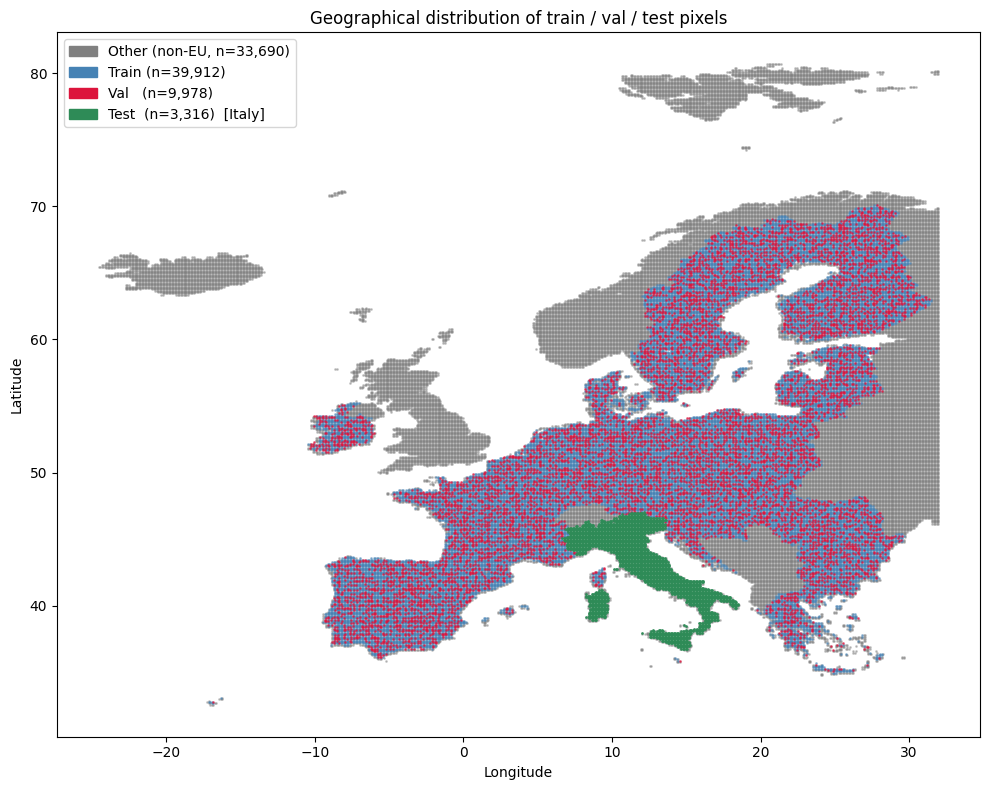

In [19]:
# Geographical representation of train / val / test split

# Load raster metadata
with rasterio.open(cisi_path) as src:
    transform = src.transform
    cisi_full = src.read(1).astype('float32')

# Build dataset (EU27 excl. Italy)
_ds = CISIDataset(gdp_path, pop_path, lc_path, cisi_path, patch_size=16, eu_mask_path=eu_mask_path)
cisi_vals = np.array([_ds.cisi[i, j] for i, j in _ds.valid_indices])

# Reproduce stratified 80/20 split
high_threshold = 0.15
high_idx = np.where(cisi_vals > high_threshold)[0]
low_idx  = np.where(cisi_vals <= high_threshold)[0]
np.random.seed(42)
np.random.shuffle(high_idx)
np.random.shuffle(low_idx)
train_idx = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
val_idx   = np.concatenate([high_idx[int(0.8*len(high_idx)):], low_idx[int(0.8*len(low_idx)):]])

def idx_to_lonlat(indices, transform):
    xs, ys = rasterio.transform.xy(transform, indices[:, 0], indices[:, 1])
    return np.array(xs), np.array(ys)

# Load EU mask
with rasterio.open(eu_mask_path) as src:
    eu_mask_arr = src.read(1).astype(bool)

# Italy pixels: use country shapefile to isolate Italy exactly
world = gpd.read_file(r'ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp')[['NAME', 'geometry']]
italy_geom = world[world['NAME'] == 'Italy'].geometry.unary_union

cisi_valid = ~np.isnan(cisi_full)
outside_eu = cisi_valid & ~eu_mask_arr
all_outside_idx = np.argwhere(outside_eu)
out_xs, out_ys = idx_to_lonlat(all_outside_idx, transform)
is_italy = np.array([italy_geom.contains(Point(x, y)) for x, y in zip(out_xs, out_ys)])
italy_idx   = all_outside_idx[is_italy]
other_idx   = all_outside_idx[~is_italy]

# Coordinates
train_lon, train_lat = idx_to_lonlat(_ds.valid_indices[train_idx], transform)
val_lon,   val_lat   = idx_to_lonlat(_ds.valid_indices[val_idx],   transform)
test_lon,  test_lat  = idx_to_lonlat(italy_idx,                    transform)
other_lon, other_lat = idx_to_lonlat(other_idx,                    transform)

# Plot -- layer order: grey other → blue train → red val → green Italy
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_facecolor('white')

ax.scatter(other_lon, other_lat, s=1, c='grey',      alpha=0.4, rasterized=True)
ax.scatter(train_lon, train_lat, s=1, c='steelblue', alpha=0.5, rasterized=True)
ax.scatter(val_lon,   val_lat,   s=1, c='crimson',   alpha=0.6, rasterized=True)
ax.scatter(test_lon,  test_lat,  s=1, c='seagreen',  alpha=0.9, rasterized=True)

handles = [
    mpatches.Patch(color='grey',      label=f'Other (non-EU, n={len(other_idx):,})'),
    mpatches.Patch(color='steelblue', label=f'Train (n={len(train_idx):,})'),
    mpatches.Patch(color='crimson',   label=f'Val   (n={len(val_idx):,})'),
    mpatches.Patch(color='seagreen',  label=f'Test  (n={len(italy_idx):,})  [Italy]'),
]
ax.legend(handles=handles, markerscale=6, fontsize=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographical distribution of train / val / test pixels')
plt.tight_layout()
plt.savefig('train_val_test_split_map.png', dpi=150, bbox_inches='tight')
plt.show()


## CISI distributions: train / val / test

- Left panel shows the full distribution (0-1); train and val should look identical due to stratified sampling
- Right panel zooms into city pixels (CISI > 0.15) to check whether Italy's urban distribution matches the training data
- A large mismatch between test and train city distributions would indicate domain shift and limit test set validity


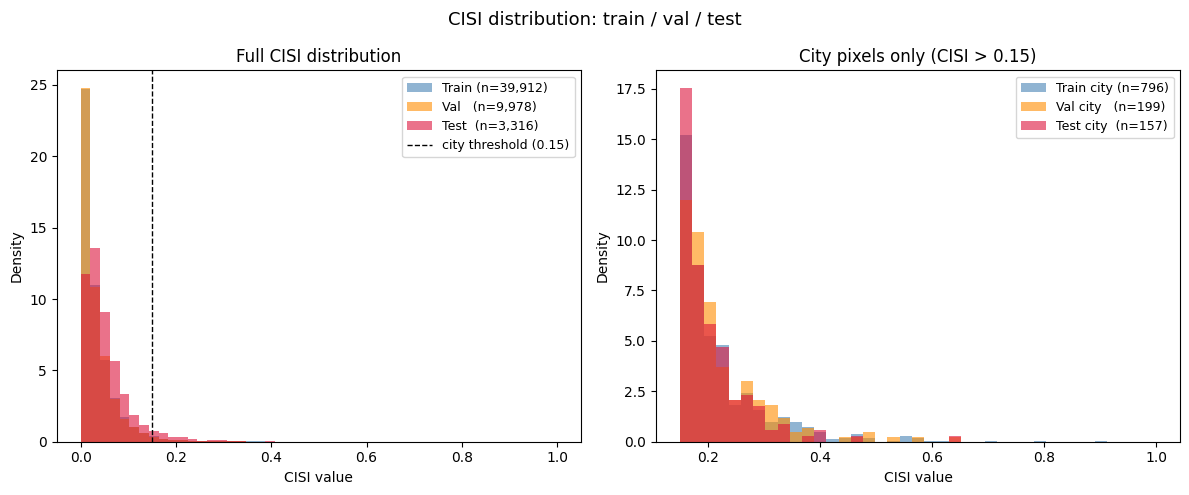

Train  mean=0.033  median=0.020  city%=2.0%  city_mean=0.222
Val    mean=0.033  median=0.020  city%=2.0%  city_mean=0.221
Test   mean=0.052  median=0.040  city%=4.7%  city_mean=0.206


In [20]:
# CISI value distributions for train / val / test pixels

# Get CISI values for each split (reuses _ds, train_idx, val_idx, italy_idx from geo plot cell)
train_cisi = cisi_vals[train_idx]
val_cisi   = cisi_vals[val_idx]
test_cisi  = np.array([cisi_full[i, j] for i, j in italy_idx])
test_cisi  = test_cisi[~np.isnan(test_cisi)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: full distribution ---
bins = np.linspace(0, 1, 50)
axes[0].hist(train_cisi, bins=bins, color='steelblue',  alpha=0.6, density=True, label=f'Train (n={len(train_cisi):,})')
axes[0].hist(val_cisi,   bins=bins, color='darkorange', alpha=0.6, density=True, label=f'Val   (n={len(val_cisi):,})')
axes[0].hist(test_cisi,  bins=bins, color='crimson',    alpha=0.6, density=True, label=f'Test  (n={len(test_cisi):,})')
axes[0].axvline(0.15, color='black', linestyle='--', linewidth=1, label='city threshold (0.15)')
axes[0].set_xlabel('CISI value')
axes[0].set_ylabel('Density')
axes[0].set_title('Full CISI distribution')
axes[0].legend(fontsize=9)

# --- Right: city pixels only (CISI > 0.15) ---
bins_city = np.linspace(0.15, 1, 40)
axes[1].hist(train_cisi[train_cisi > 0.15], bins=bins_city, color='steelblue',  alpha=0.6, density=True, label=f'Train city (n={( train_cisi > 0.15).sum():,})')
axes[1].hist(val_cisi[val_cisi > 0.15],     bins=bins_city, color='darkorange', alpha=0.6, density=True, label=f'Val city   (n={(val_cisi   > 0.15).sum():,})')
axes[1].hist(test_cisi[test_cisi > 0.15],   bins=bins_city, color='crimson',    alpha=0.6, density=True, label=f'Test city  (n={(test_cisi  > 0.15).sum():,})')
axes[1].set_xlabel('CISI value')
axes[1].set_ylabel('Density')
axes[1].set_title('City pixels only (CISI > 0.15)')
axes[1].legend(fontsize=9)

plt.suptitle('CISI distribution: train / val / test', fontsize=13)
plt.tight_layout()
plt.savefig('train_val_test_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
for name, arr in [('Train', train_cisi), ('Val', val_cisi), ('Test', test_cisi)]:
    city = arr[arr > 0.15]
    print(f'{name:5s}  mean={arr.mean():.3f}  median={np.median(arr):.3f}  '
          f'city%={100*len(city)/len(arr):.1f}%  city_mean={city.mean():.3f}')


In [21]:
# with rasterio.open(r'READY_data\labels\2024_CISI_010deg_nearest.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Paths 0.25

In [22]:
# gdp_path = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
# pop_path = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
# lc_path = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"
# cisi_path = r"READY_data\labels\CISI_025deg_corrected.tif"

In [23]:
# with rasterio.open(r'READY_data\labels\CISI_025deg_corrected.tif') as src:
#     data = src.read(1)
#     print(f"Shape: {data.shape}")
#     print(f"Max: {np.nanmax(data):.4f}")

# Dataset and Split

In [24]:
# dataset = CISIDataset(gdp_path, pop_path, lc_path, cisi_path, eu_mask_path=eu_mask_path)
# cisi_values = np.array([dataset.cisi[i, j] for i, j in dataset.valid_indices])

# high_threshold = 0.15
# high_indices = np.where(cisi_values > high_threshold)[0]
# low_indices  = np.where(cisi_values <= high_threshold)[0]

# np.random.seed(42)
# np.random.shuffle(high_indices)
# np.random.shuffle(low_indices)

# train_idx = np.concatenate([high_indices[:int(0.8*len(high_indices))],
#                              low_indices[:int(0.8*len(low_indices))]])
# val_idx   = np.concatenate([high_indices[int(0.8*len(high_indices)):],
#                              low_indices[int(0.8*len(low_indices)):]])

# train_dataset = Subset(dataset, train_idx)
# val_dataset   = Subset(dataset, val_idx)

# print(f"Train: {len(train_dataset):,}, Val: {len(val_dataset):,}")

# cisi_train = cisi_values[train_idx]
# n_high = (cisi_train > high_threshold).sum()
# n_low  = (cisi_train <= high_threshold).sum()
# w_high = len(cisi_train) / n_high
# w_low  = len(cisi_train) / n_low
# sample_weights = np.where(cisi_train > high_threshold, w_high, w_low)
# print(f"Sampler weights — high: {w_high:.1f}x, low: {w_low:.2f}x")

# Create Dataloaders

In [25]:
# batch_size = 32

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True)
# val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, drop_last=True)

In [26]:
# train_targets = []
# val_targets = []

# for _, target, _ in train_loader:
#     train_targets.extend(target.numpy().flatten())

# for _, target, _ in val_loader:
#     val_targets.extend(target.numpy().flatten())

# train_targets = np.array(train_targets)
# val_targets = np.array(val_targets)

# print("TRAIN SET:")
# print(f"  Mean: {train_targets.mean():.4f}, Std: {train_targets.std():.4f}")
# print(f"  Range: [{train_targets.min():.4f}, {train_targets.max():.4f}]")

# print("\nVAL SET:")
# print(f"  Mean: {val_targets.mean():.4f}, Std: {val_targets.std():.4f}")
# print(f"  Range: [{val_targets.min():.4f}, {val_targets.max():.4f}]")

# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# axes[0].hist(train_targets, bins=50, alpha=0.7, label='Train')
# axes[0].set_title('Train CISI Distribution')
# axes[0].set_xlabel('CISI')

# axes[1].hist(val_targets, bins=50, alpha=0.7, label='Val', color='orange')
# axes[1].set_title('Validation CISI Distribution')
# axes[1].set_xlabel('CISI')

# plt.tight_layout()
# plt.show()

# Init Model

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# config = {'dropout': 0.3}
# model = CNN(config).to(device)
# criterion = WeibullWeightedMSELoss(kappa=28.0, alpha=2.75)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)

Using device: cpu


# Train Model

In [28]:
# vars
# nummber_of_epochs = 50

In [29]:
# train_loss_list, val_loss_list = training(
#     num_epochs=nummber_of_epochs,
#     model=model,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     criterion=criterion,
#     optimizer=optimizer,
#     clip_value=1.0,
#     device=device,
#     scheduler=scheduler
# )

# Plotting some results

In [30]:
# plt.figure(figsize=(10, 5))
# plt.plot(train_loss_list, label='Train Loss')
# plt.plot(val_loss_list, label='Validation Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()
# plt.title('Training Progress')
# plt.show()

# Full Dataset Evaluation

In [31]:
# model.eval()
# all_preds, all_targets = [], []

# with torch.no_grad():
#     for batch in val_loader:
#         inputs, targets, _ = batch
#         inputs = inputs.to(device)
#         outputs = model(inputs)
#         all_preds.append(outputs.cpu())
#         all_targets.append(targets)

# preds   = torch.cat(all_preds).numpy().flatten()
# targets = torch.cat(all_targets).numpy().flatten()

# from sklearn.metrics import r2_score, mean_absolute_error
# print(f"Pred range:            {preds.min():.4f} - {preds.max():.4f}")
# print(f"Pred mean:             {preds.mean():.4f}  (target mean: {targets.mean():.4f})")
# print(f"High CISI pred mean:   {preds[targets > 0.15].mean():.4f}")
# print(f"High CISI target mean: {targets[targets > 0.15].mean():.4f}")
# print(f"City underprediction:  {(1 - preds[targets>0.2].mean()/targets[targets>0.2].mean())*100:.1f}%")
# print(f"\nGlobal R2:  {r2_score(targets, preds):.4f}")
# print(f"Global MAE: {mean_absolute_error(targets, preds):.4f}")
# print(f"City R2:    {r2_score(targets[targets>0.2], preds[targets>0.2]):.4f}")
# print(f"City MAE:   {mean_absolute_error(targets[targets>0.2], preds[targets>0.2]):.4f}")

In [32]:
# Load best model (Exp102)
# model.eval()
# all_preds = []
# all_targets = []

# with torch.no_grad():
#     for batch in val_loader:
#         inputs, targets, _ = batch
#         inputs = inputs.to(device)
#         outputs = model(inputs)
#         all_preds.append(outputs.cpu())
#         all_targets.append(targets)

# preds = torch.cat(all_preds).numpy().flatten()
# targets = torch.cat(all_targets).numpy().flatten()

# Diagnostics
# print(f"Pred range: {preds.min():.4f} - {preds.max():.4f}")
# print(f"Pred mean: {preds.mean():.4f}")
# print(f"Target mean: {targets.mean():.4f}")
# print(f"High CISI pixels (>0.2): {(targets > 0.2).mean()*100:.1f}%")
# print(f"High CISI pred mean: {preds[targets > 0.2].mean():.4f}")
# print(f"High CISI target mean: {targets[targets > 0.2].mean():.4f}")

# Generate predictions

In [33]:
# model.eval()
# predictions = []
# actuals = []
# coordinates = []

# with torch.no_grad():
#     for batch in val_loader:
#         inputs, targets, coords = batch
#         inputs = inputs.to(device)
        
#         outputs = model(inputs)
        
#         predictions.extend(outputs.cpu().numpy().flatten())
#         actuals.extend(targets.numpy().flatten())
#         coordinates.extend(coords)

# predictions = np.array(predictions)
# actuals = np.array(actuals)

# print(f"Predictions range: [{predictions.min():.3f}, {predictions.max():.3f}]")
# print(f"Actuals range: [{actuals.min():.3f}, {actuals.max():.3f}]")

# Visualize Results

In [34]:
# plt.figure(figsize=(8, 8))
# plt.scatter(actuals, predictions, alpha=0.5, s=10)
# plt.plot([0, 1], [0, 1], 'r--', label='Perfect prediction')
# plt.xlabel('Actual CISI')
# plt.ylabel('Predicted CISI')
# plt.title('Predictions vs Actuals')
# plt.legend()
# plt.grid(True)
# plt.show()

# Metrics

In [35]:
# mse = mean_squared_error(actuals, predictions)
# mae = mean_absolute_error(actuals, predictions)
# rmse = np.sqrt(mse)
# r2 = r2_score(actuals, predictions)

# print(f"MSE: {mse:.4f}")
# print(f"MAE: {mae:.4f}")
# print(f"RMSE: {rmse:.4f}")
# print(f"R² Score: {r2:.4f}")

In [36]:
# Check distributions
# print("=== ACTUALS ===")
# print(f"Mean: {actuals.mean():.4f}")
# print(f"Std: {actuals.std():.4f}")
# print(f"Range: [{actuals.min():.4f}, {actuals.max():.4f}]")

# print("\n=== PREDICTIONS ===")
# print(f"Mean: {predictions.mean():.4f}")
# print(f"Std: {predictions.std():.4f}")
# print(f"Range: [{predictions.min():.4f}, {predictions.max():.4f}]")

# Plot histograms
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# axes[0].hist(actuals, bins=50, alpha=0.7, label='Actuals')
# axes[0].set_title('Distribution of Actual CISI')
# axes[0].set_xlabel('CISI Value')
# axes[0].legend()

# axes[1].hist(predictions, bins=50, alpha=0.7, label='Predictions', color='orange')
# axes[1].set_title('Distribution of Predicted CISI')
# axes[1].set_xlabel('CISI Value')
# axes[1].legend()

# plt.tight_layout()
# plt.show()

In [37]:
# Look at one sample from dataset
# sample_input, sample_target, _ = dataset[0]

# print("Input shape:", sample_input.shape)
# print("\nInput statistics per channel:")
# for i in range(9):
#     channel = sample_input[i]
#     print(f"Channel {i}: min={channel.min():.2f}, max={channel.max():.2f}, mean={channel.mean():.2f}")

# print(f"\nTarget CISI value: {sample_target.item():.4f}")

# Generate Predictions on Full Training Set

In [38]:
# # Generate predictions on ALL training data
# model.eval()
# all_preds = []
# all_actuals = []
# all_indices = []

# with torch.no_grad():
#     for inputs, targets, indices in train_loader:
#         inputs = inputs.to(device)
#         outputs = model(inputs)
        
#         all_preds.extend(outputs.cpu().numpy().flatten())
#         all_actuals.extend(targets.cpu().numpy().flatten())
#         all_indices.extend(indices)

# all_preds = np.array(all_preds)
# all_actuals = np.array(all_actuals)

# # Split by city/rural
# city_mask = all_actuals > 0.1
# rural_mask = all_actuals <= 0.1

# print(f"\n{'='*80}")
# print("TRAINING SET: CITY vs RURAL")
# print(f"{'='*80}")

# print(f"\n CITIES (CISI > 0.1):")
# print(f"  Count: {city_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[city_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[city_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[city_mask], all_preds[city_mask]):.4f}")

# print(f"\n RURAL (CISI ≤ 0.1):")
# print(f"  Count: {rural_mask.sum():,}")
# print(f"  Actual mean: {all_actuals[rural_mask].mean():.4f}")
# print(f"  Pred mean: {all_preds[rural_mask].mean():.4f}")
# print(f"  MAE: {mean_absolute_error(all_actuals[rural_mask], all_preds[rural_mask]):.4f}")

# Save model

In [39]:
# save_model_checkpoint(
#     model, optimizer, train_loss_list, val_loss_list, config,
#     save_name='exp111',
#     dataset=dataset,
#     train_dataset=train_dataset,
#     val_dataset=val_dataset,
#     criterion=criterion,
#     learning_rate=0.0005,
#     batch_size=batch_size,
#     num_epochs=nummber_of_epochs,
#     patch_size=32
# )

# W&B Hyperparameter Sweep

## Stage 1 — Broad architecture search (100 runs)

**Metric optimised:** `train_rmse`, minimise. Full search space: lr, weight_decay, batch_size, dropout, patch_size [8, 16, 32], n_layers [2–4], base_channels [16, 32, 64], loss_fn (weibull, huber, weighted_mse) + loss-specific parameters.

**Purpose:** Identify which architectural choices dominate performance before refining. Found that `patch_size=8` and `base_channels=32` consistently produced the best results; larger patches and more channels gave no gain.

---

## Stage 2 — Narrowed search optimising city accuracy (77 runs)

`patch_size=8` and `base_channels=32` fixed from Stage 1. **Metric:** `val_city_rmse` (RMSE on val pixels where CISI > 0.15), minimise. Stratified 80/20 split introduced (seed=42) to guarantee city pixels in both train and val.

**Purpose:** Directly optimise for the metric that matters — city pixel accuracy — rather than global RMSE which is dominated by the 98% rural pixels.

**Best result (row 164):** weighted_mse loss, lr≈5.7e-5, dropout=0.3, n_layers=3 → **city_rmse=0.067**, city_mae=0.049. Results in `sweep_results.csv`.

---

## Stage 3 — WeightedRandomSampler (50 runs)

Adds `WeightedRandomSampler` with `oversample_factor` ∈ {5, 10, 20, 40} to oversample city pixels during training. **Metric:** `val_city_rmse`, minimise. Early stopping on `val_city_rmse`.

**Purpose:** Address class imbalance by making the model see more city pixels per batch, without changing the loss function or evaluation set.

**Result:** best city_rmse=0.080, worse than Stage 2. WRS increases prediction variance on the 199-pixel val city set, making `val_city_rmse` a noisier Bayesian target. Results in `sweep_results_s3.csv`.

---

## Stage 4 — WRS + stable val_rmse signal (95+ runs)

Same as Stage 3 but switches metric and early stopping to `val_rmse` (global, 9,978 val pixels) to give the Bayesian optimiser a more stable signal.

**Purpose:** Test whether a more stable optimisation target improves city metrics indirectly.

**Result:** best city_rmse=0.084, worst of all stages. Early stopping on `val_rmse` saves a rural-optimal checkpoint; city metrics evaluated on those weights are suboptimal. Results in `sweep_results_s4.csv`.

---

## Stage 5 — Data augmentation (50 runs)

Removes WRS. Adds random 90°/180°/270° rotation to city patches (CISI > 0.15) at load time (`augment=True` on train dataset only; val uses `augment=False`). **Metric:** `val_city_rmse`, minimise. Early stopping on `val_city_rmse`.

**Purpose:** Attack the root cause — too few distinct city patches — by increasing spatial diversity ~4× per epoch without changing the sampling distribution. Two separate `CISIDataset` instances share the same split indices; only the train instance augments. Results in `sweep_results_s5.csv`.

---

## Summary for thesis write-up

| Stage | Runs | Key change | Best val city_rmse |
|-------|------|------------|-------------------|
| 1 | 100 | Broad architecture search, train_rmse metric | — (architecture selection only) |
| 2 | 77  | Fixed architecture, val_city_rmse metric, stratified split | **0.067** |
| 3 | 50  | + WeightedRandomSampler (oversample_factor sweep) | 0.080 |
| 4 | 95+ | WRS + val_rmse early stopping | 0.084 |
| 5 | 50  | Data augmentation (city patch rotation) | pending |

After Stage 5: ensemble top-5 configs from best stage(s), retrain deterministically, average predictions.

In [40]:
SWEEP_PROJECT   = 'cisi-hyperparameter-sweep'
BEST_MODEL_PATH = 'best_sweep_model.pt'
SWEEP_CSV       = 'sweep_results_s5.csv'  # Stage 5 — data augmentation + val_city_rmse

sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_city_rmse', 'goal': 'minimize'},
    'parameters': {
        # Optimiser
        'lr':           {'distribution': 'log_uniform_values', 'min': 1e-5, 'max': 1e-3},
        'weight_decay': {'distribution': 'log_uniform_values', 'min': 1e-6, 'max': 1e-3},
        'batch_size':   {'values': [16, 32]},
        # Regularisation
        'dropout':      {'values': [0.1, 0.2, 0.3]},
        # Architecture — fixed from Stage 1/2
        'patch_size':   {'value': 8},
        'n_layers':     {'values': [2, 3]},
        'base_channels':{'value': 32},
        # Loss function
        'loss_fn':      {'values': ['weibull', 'huber', 'weighted_mse']},
        # Weibull-specific (ignored when loss_fn != weibull)
        'kappa':        {'values': [5.0, 15.0, 28.0, 45.0]},
        'alpha':        {'values': [1.5, 2.0, 2.75, 3.5]},
        # Huber-specific (ignored when loss_fn != huber)
        'delta':        {'values': [0.05, 0.1, 0.2]},
        # WeightedMSE-specific (ignored when loss_fn != weighted_mse)
        'scale':        {'values': [5.0, 10.0, 20.0]},
    }
}

sweep_id = wandb.sweep(sweep_config, project=SWEEP_PROJECT)
print('Sweep ID:', sweep_id)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


Create sweep with ID: zaa0u92x
Sweep URL: https://wandb.ai/mjm060323-university-of-amsterdam/cisi-hyperparameter-sweep/sweeps/zaa0u92x
Sweep ID: zaa0u92x


In [41]:
class CNNSweep(nn.Module):
    """
    CNN with configurable:
      - patch_size: input spatial size (8, 16, 32)
      - n_layers: number of conv blocks (2, 3, 4)
      - base_channels: first layer channels; doubles each block (8->16->32->64 etc.)
      - dropout: dropout rate
    """
    def __init__(self, config):
        super().__init__()
        d            = config.get('dropout', 0.3)
        n_layers     = config.get('n_layers', 4)
        base_ch      = config.get('base_channels', 16)
        self.patch_size = config.get('patch_size', 16)

        layers = []
        in_ch  = 9
        out_ch = base_ch
        for i in range(n_layers):
            layers += [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(),
                nn.Dropout(d),
            ]
            # Add pooling on all but last layer
            if i < n_layers - 1:
                layers.append(nn.MaxPool2d(2, 2))
            in_ch  = out_ch
            out_ch = min(out_ch * 2, 256)  # cap at 256

        self.conv_layers = nn.Sequential(*layers)
        self.final_ch    = in_ch

        self.fc_layers = nn.Sequential(
            nn.Linear(self.final_ch, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(d),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x[:, :, 1, 1]
        x = self.fc_layers(x)
        return torch.sigmoid(x)


def build_criterion(cfg):
    loss_fn = cfg.get('loss_fn', 'weibull')
    if loss_fn == 'weibull':
        return WeibullWeightedMSELoss(kappa=cfg.get('kappa', 28.0), alpha=cfg.get('alpha', 2.75))
    elif loss_fn == 'huber':
        return nn.HuberLoss(delta=cfg.get('delta', 0.1))
    elif loss_fn == 'weighted_mse':
        return WeightedMSELoss(scale=cfg.get('scale', 5.0))
    else:  # mse
        return nn.MSELoss()


In [42]:
def train_sweep():
    set_seed(42)
    run = wandb.init()
    wandb.define_metric('val_city_rmse', summary='min')
    cfg = run.config

    try:
        patch_size = cfg.patch_size
        batch_size = cfg.batch_size

        # Two separate instances: train with augmentation, val without
        train_full = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
                                 patch_size=patch_size, eu_mask_path=eu_mask_path, augment=True)
        val_full   = CISIDataset(gdp_path, pop_path, lc_path, cisi_path,
                                 patch_size=patch_size, eu_mask_path=eu_mask_path, augment=False)

        cisi_vals = np.array([train_full.cisi[i, j] for i, j in train_full.valid_indices])
        high_idx  = np.where(cisi_vals > 0.15)[0]
        low_idx   = np.where(cisi_vals <= 0.15)[0]
        rng = np.random.RandomState(42)
        rng.shuffle(high_idx)
        rng.shuffle(low_idx)
        train_idx = np.concatenate([high_idx[:int(0.8*len(high_idx))], low_idx[:int(0.8*len(low_idx))]])
        val_idx   = np.concatenate([high_idx[int(0.8*len(high_idx)):], low_idx[int(0.8*len(low_idx)):]])
        train_ds  = Subset(train_full, train_idx)
        val_ds    = Subset(val_full,   val_idx)

        g = torch.Generator()
        g.manual_seed(42)

        s_train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                                    worker_init_fn=seed_worker, generator=g)
        s_val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                                    worker_init_fn=seed_worker, generator=g)

        model     = CNNSweep(dict(cfg)).to(device)
        criterion = build_criterion(dict(cfg))
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-6)
        es        = EarlyStopping(patience=10, delta=0.01)
        history   = {'train_rmse': [], 'train_city_rmse': [], 'val_rmse': [], 'val_city_rmse': []}

        for epoch in range(100):
            model.train()
            tr_preds, tr_targets = [], []
            for inputs, targets, _ in s_train_loader:
                inputs, targets_dev = inputs.to(device), targets.to(device).view(-1, 1)
                optimizer.zero_grad()
                out = model(inputs)
                loss = criterion(out, targets_dev)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                tr_preds.extend(out.detach().cpu().numpy().flatten())
                tr_targets.extend(targets.numpy().flatten())

            tr_preds   = np.array(tr_preds)
            tr_targets = np.array(tr_targets)
            tr_city    = tr_targets > 0.15
            train_rmse      = float(np.sqrt(np.mean((tr_targets - tr_preds) ** 2)))
            train_city_rmse = float(np.sqrt(np.mean((tr_targets[tr_city] - tr_preds[tr_city]) ** 2))) \
                              if tr_city.sum() > 10 else 999.0

            model.eval()
            ep_preds, ep_targets = [], []
            with torch.no_grad():
                for inputs, targets, _ in s_val_loader:
                    out = model(inputs.to(device))
                    ep_preds.extend(out.cpu().numpy().flatten())
                    ep_targets.extend(targets.numpy().flatten())

            ep_preds   = np.array(ep_preds)
            ep_targets = np.array(ep_targets)
            ep_city    = ep_targets > 0.15
            val_rmse      = float(np.sqrt(np.mean((ep_targets - ep_preds) ** 2)))
            val_city_rmse = float(np.sqrt(np.mean((ep_targets[ep_city] - ep_preds[ep_city]) ** 2))) \
                            if ep_city.sum() > 10 else 999.0

            history['train_rmse'].append(train_rmse)
            history['train_city_rmse'].append(train_city_rmse)
            history['val_rmse'].append(val_rmse)
            history['val_city_rmse'].append(val_city_rmse)

            wandb.log({'epoch': epoch, 'train_rmse': train_rmse, 'train_city_rmse': train_city_rmse,
                       'val_rmse': val_rmse, 'val_city_rmse': val_city_rmse})
            scheduler.step()

            es(val_city_rmse, model)
            if es.early_stop:
                print('Early stop at epoch', epoch)
                break

        model.load_state_dict(es.best_weights)
        model.eval()
        preds, targets_all = [], []
        with torch.no_grad():
            for inputs, targets, _ in s_val_loader:
                preds.extend(model(inputs.to(device)).cpu().numpy().flatten())
                targets_all.extend(targets.numpy().flatten())

        preds       = np.array(preds)
        targets_all = np.array(targets_all)
        city_mask   = targets_all > 0.15

        global_mae  = float(mean_absolute_error(targets_all, preds))
        global_rmse = float(np.sqrt(np.mean((targets_all - preds) ** 2)))
        city_mae    = float(mean_absolute_error(targets_all[city_mask], preds[city_mask])) if city_mask.sum() > 10 else 999.0
        city_rmse   = float(np.sqrt(np.mean((targets_all[city_mask] - preds[city_mask]) ** 2))) if city_mask.sum() > 10 else 999.0
        city_underpred = float(np.mean(targets_all[city_mask] - preds[city_mask])) if city_mask.sum() > 10 else 999.0

        try:
            _tr_city = tr_targets > 0.15
            train_city_rmse_final = float(np.sqrt(np.mean((tr_targets[_tr_city] - tr_preds[_tr_city]) ** 2))) \
                                    if _tr_city.sum() > 10 else 999.0
        except Exception:
            train_city_rmse_final = 999.0

        wandb.log({'train_city_rmse': train_city_rmse_final,
                   'global_mae': global_mae, 'global_rmse': global_rmse,
                   'city_mae': city_mae, 'city_rmse': city_rmse,
                   'city_underprediction': city_underpred, 'pred_max': float(preds.max())})

        try:
            global best_train_rmse
            if global_rmse < best_train_rmse:
                best_train_rmse = global_rmse
                torch.save({'model_state_dict': es.best_weights, 'config': dict(cfg),
                            'global_rmse': global_rmse, 'city_mae': city_mae,
                            'city_rmse': city_rmse, 'global_mae': global_mae}, BEST_MODEL_PATH)
                print('New best -- global_rmse=' + str(round(global_rmse, 4)))
        except Exception as e:
            print('Model save skipped:', e)

        row = {
            'loss_fn': cfg.loss_fn, 'kappa': cfg.get('kappa', None), 'alpha': cfg.get('alpha', None),
            'lr': cfg.lr, 'dropout': cfg.dropout, 'patch_size': patch_size,
            'batch_size': batch_size, 'n_layers': cfg.n_layers, 'base_channels': cfg.base_channels,
            'weight_decay': cfg.weight_decay,
            'global_mae': global_mae, 'global_rmse': global_rmse,
            'city_mae': city_mae, 'city_rmse': city_rmse,
            'train_city_rmse': train_city_rmse_final,
            'city_underprediction': city_underpred, 'pred_max': float(preds.max()),
        }
        write_header = not os.path.exists(SWEEP_CSV)
        with open(SWEEP_CSV, 'a', newline='') as f:
            w = csv.DictWriter(f, fieldnames=list(row.keys()))
            if write_header: w.writeheader()
            w.writerow(row)

        epochs_list = list(range(len(history['train_rmse'])))
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(epochs_list, history['train_rmse'], label='train_rmse', color='steelblue')
        axes[0].plot(epochs_list, history['val_rmse'],   label='val_rmse',   color='crimson')
        axes[0].set_title('Global RMSE'); axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('RMSE'); axes[0].legend()
        axes[1].plot(epochs_list, history['train_city_rmse'], label='train_city_rmse', color='steelblue')
        axes[1].plot(epochs_list, history['val_city_rmse'],   label='val_city_rmse',   color='crimson')
        axes[1].set_title('City RMSE (CISI > 0.15)'); axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('RMSE'); axes[1].legend()
        plt.tight_layout()
        wandb.log({'training_curves': wandb.Image(fig)})
        plt.close(fig)

    except Exception as e:
        import traceback
        print('RUN FAILED:', e)
        traceback.print_exc()

    finally:
        run.finish()


## Run W&B

Resuming -- current best global_rmse: 0.0315


wandb: Agent Starting Run: 5fw90oyt with config:
wandb: 	alpha: 3.5
wandb: 	base_channels: 32
wandb: 	batch_size: 16
wandb: 	delta: 0.1
wandb: 	dropout: 0.2
wandb: 	kappa: 5
wandb: 	loss_fn: weighted_mse
wandb: 	lr: 3.184773031555333e-05
wandb: 	n_layers: 3
wandb: 	patch_size: 8
wandb: 	scale: 5
wandb: 	weight_decay: 0.00034651889984845826
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: mjm060323 (mjm060323-university-of-amsterdam). Use `wandb login --relogin` to force relogin


EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
Early stop at epoch 11


city_mae,▁
city_rmse,▁
city_underprediction,▁
epoch,▁▂▂▃▄▄▅▅▆▇▇█
global_mae,▁
global_rmse,▁
pred_max,▁
train_city_rmse,█▁▂▃▃▃▃▃▃▃▃▃▃
train_rmse,█▄▂▁▁▁▁▁▁▁▁▁
val_city_rmse,▄▁▆██▆█▇▇▆█▅
val_rmse,█▄▂▁▁▁▁▁▁▁▁▁


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: psxbzhgv with config:
wandb: 	alpha: 2
wandb: 	base_channels: 32
wandb: 	batch_size: 16
wandb: 	delta: 0.1
wandb: 	dropout: 0.1
wandb: 	kappa: 15
wandb: 	loss_fn: weibull
wandb: 	lr: 4.543712415757868e-05
wandb: 	n_layers: 2
wandb: 	patch_size: 8
wandb: 	scale: 5
wandb: 	weight_decay: 0.000349361187012931
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


...

wandb: Agent Starting Run: 2oy6ccft with config:
wandb: 	alpha: 3.5
wandb: 	base_channels: 32
wandb: 	batch_size: 32
wandb: 	delta: 0.2
wandb: 	dropout: 0.2
wandb: 	kappa: 5
wandb: 	loss_fn: weighted_mse
wandb: 	lr: 1.1163862243800302e-05
wandb: 	n_layers: 2
wandb: 	patch_size: 8
wandb: 	scale: 5
wandb: 	weight_decay: 0.000986815637929066
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
EU mask applied: Italy and non-EU countries excluded
Found 49,890 valid pixels (patch_size=8)
Early stop at epoch 15
RUN FAILED: [Errno 2] No such file or directory: 'C:\\Users\\Gebruiker\\AppData\\Local\\Temp\\tmp8iso0c8jwandb-media\\5eheb188.png'


Traceback (most recent call last):
  File "C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_51192\3536851537.py", line 161, in train_sweep
    wandb.log({'training_curves': wandb.Image(fig)})
                                  ^^^^^^^^^^^^^^^^
  File "c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\wandb\sdk\data_types\image.py", line 179, in __init__
    self._initialize_from_data(data_or_path, mode, file_type)
  File "c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\wandb\sdk\data_types\image.py", line 336, in _initialize_from_data
    self._image.save(tmp_path, transparency=None)
  File "c:\Users\Gebruiker\AppData\Local\Programs\Python\Python311\Lib\site-packages\PIL\Image.py", line 2456, in save
    fp = builtins.open(filename, "w+b")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Gebruiker\\AppData\\Local\\Temp\\tmp8iso0c8jwandb-media\\5eheb188.png'


city_mae,▁
city_rmse,▁
city_underprediction,▁
epoch,▁▁▂▂▃▃▄▄▅▅▆▆▇▇██
global_mae,▁
global_rmse,▁
pred_max,▁
train_city_rmse,█▅▃▂▁▁▁▁▁▂▂▂▃▃▃▃▃
train_rmse,█▇▆▅▄▄▃▃▂▂▂▁▁▁▁▁
val_city_rmse,█▆▄▃▂▁▁▁▂▂▃▃▃▃▄▄
val_rmse,█▇▆▅▅▄▃▃▂▂▂▁▁▁▁▁


Sweep complete. Best model saved to best_sweep_model.pt


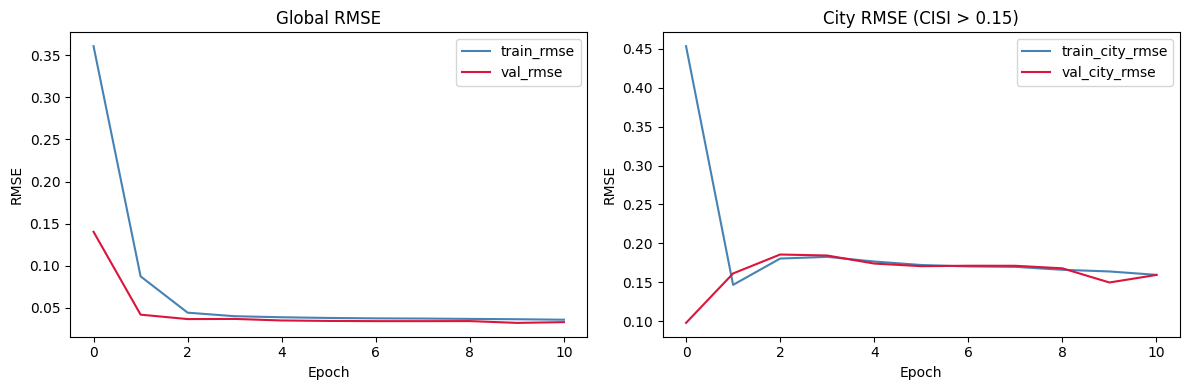

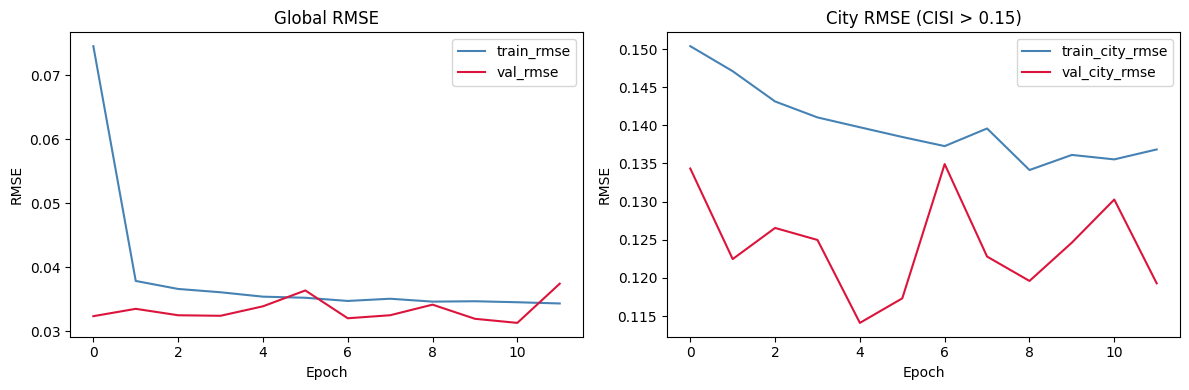

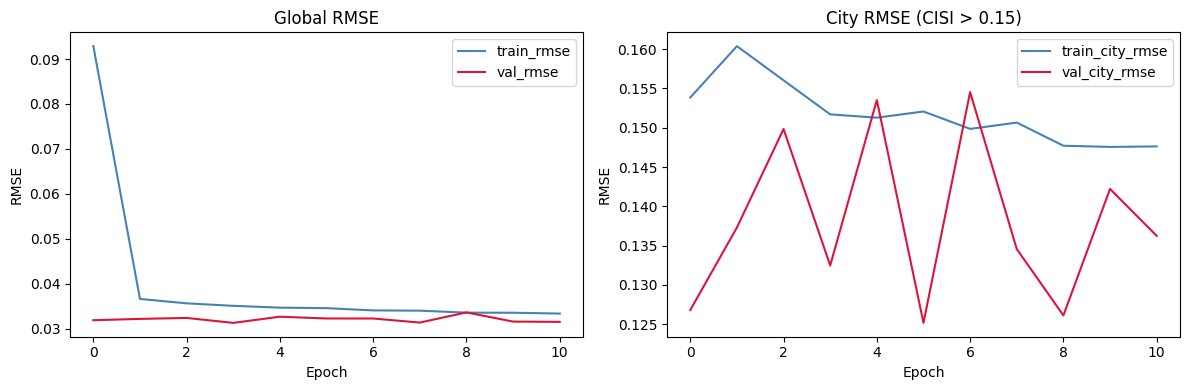

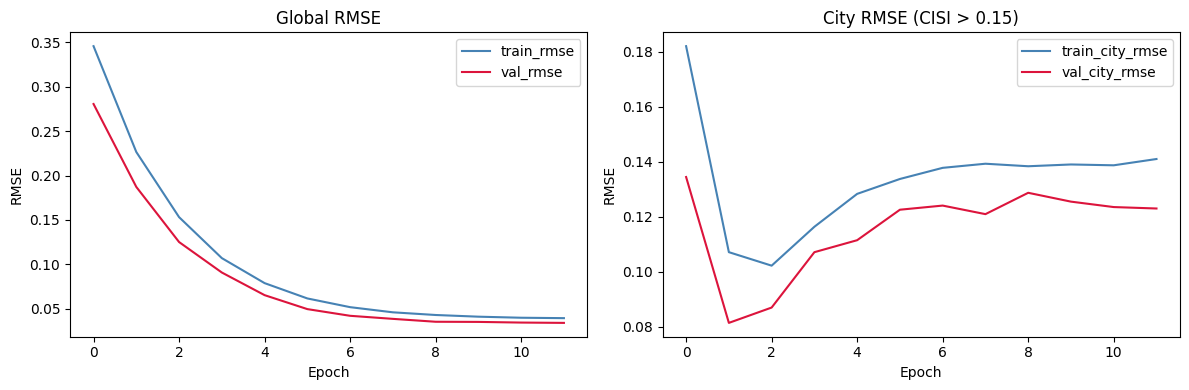

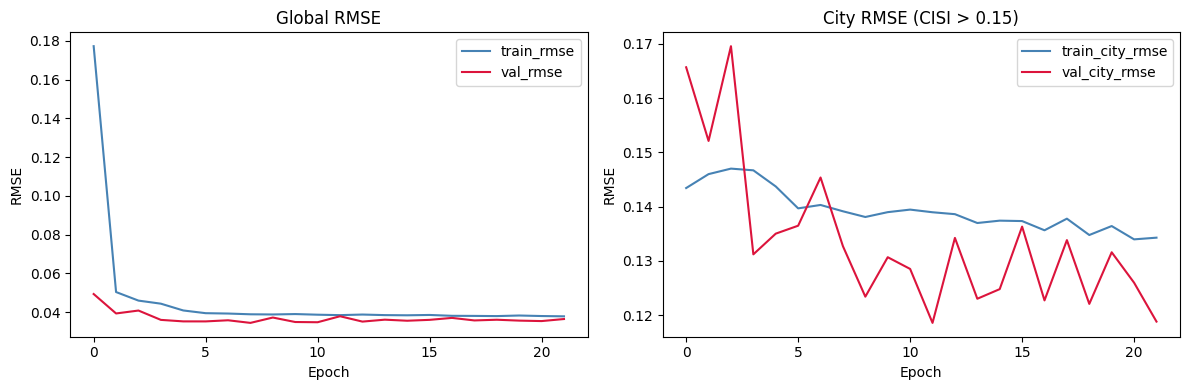

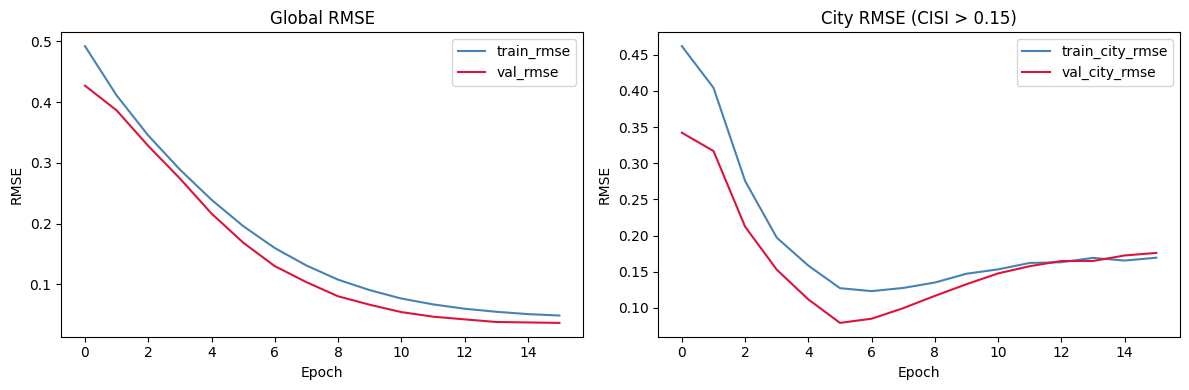

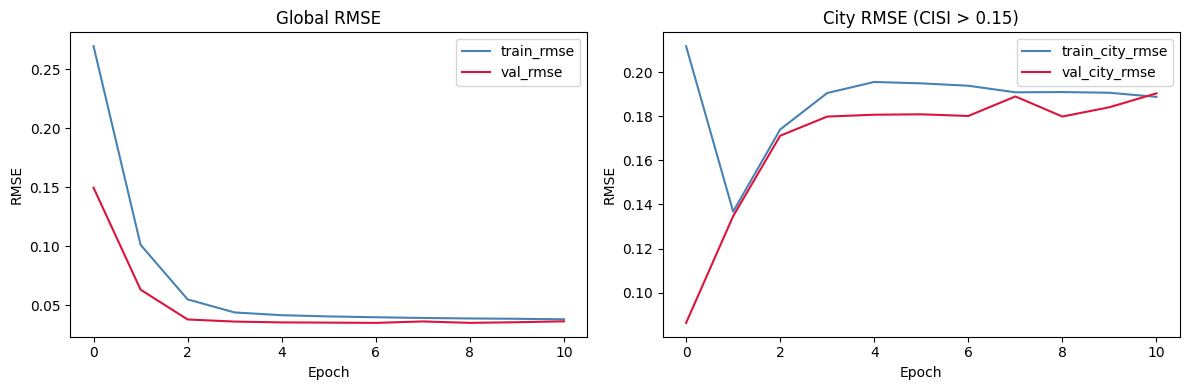

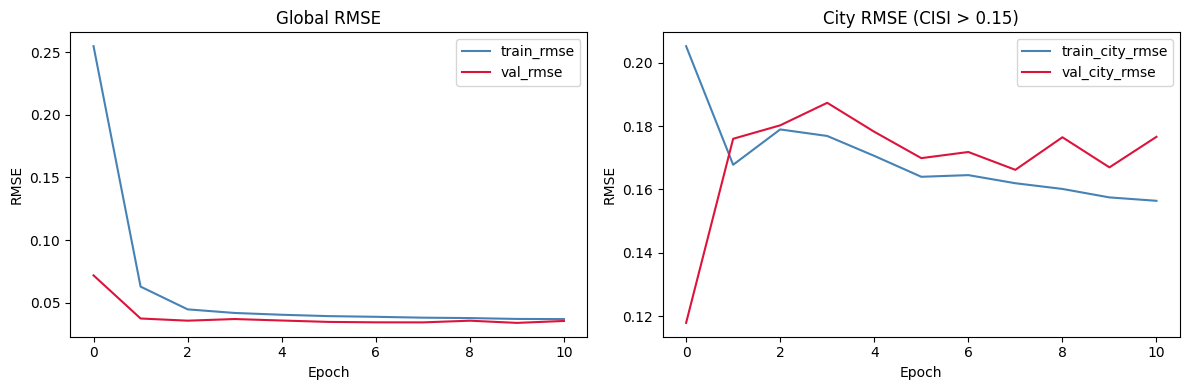

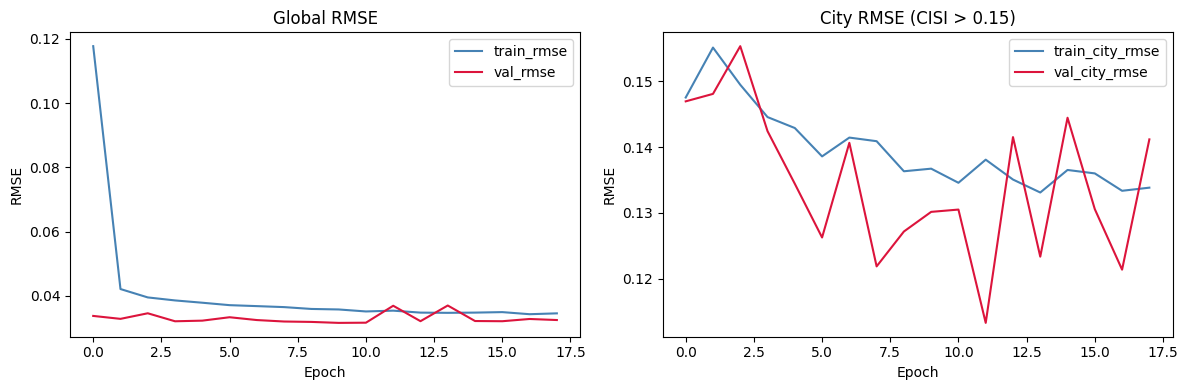

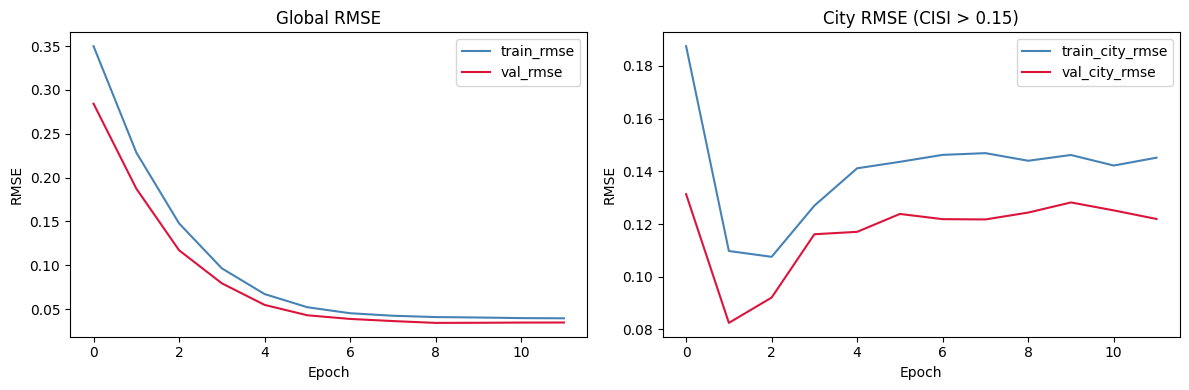

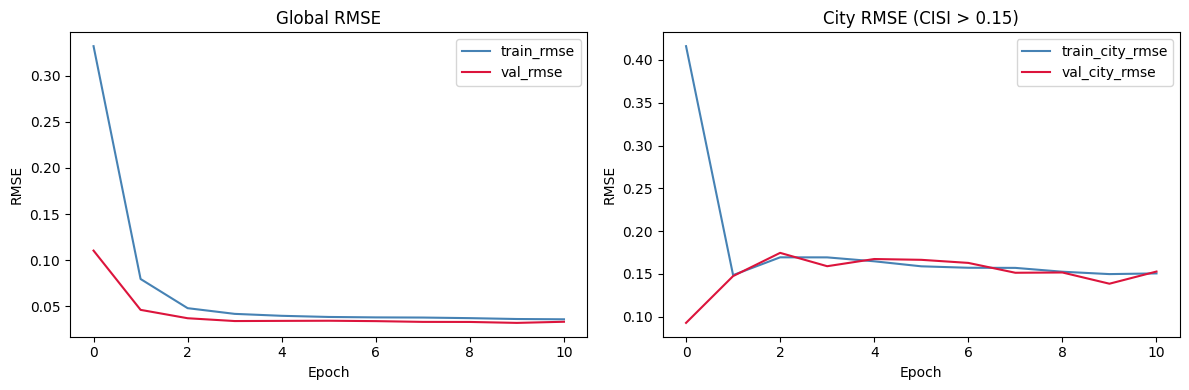

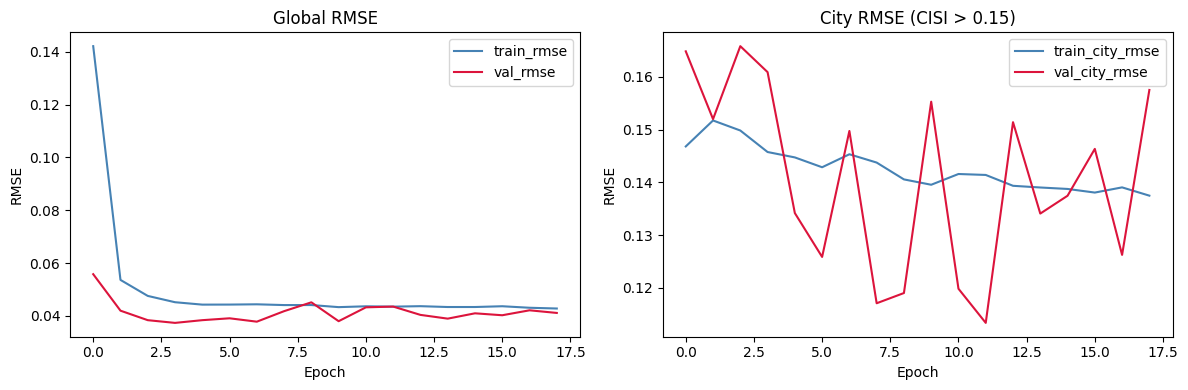

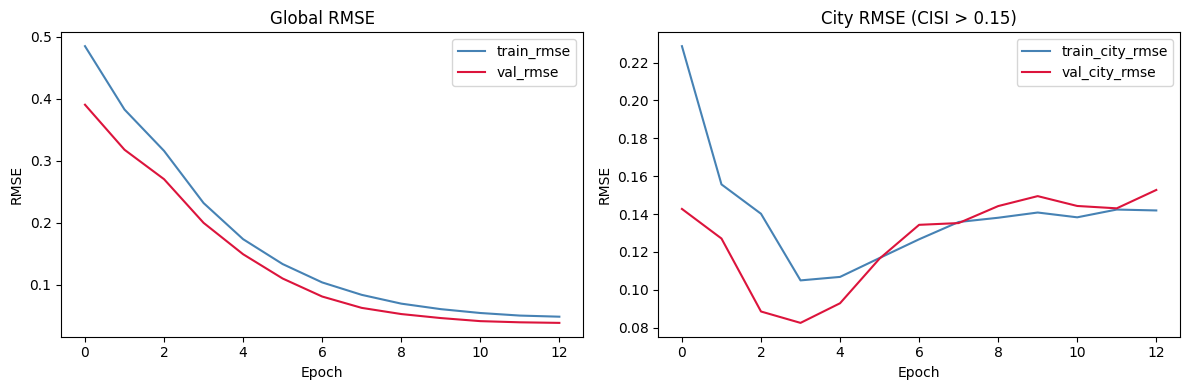

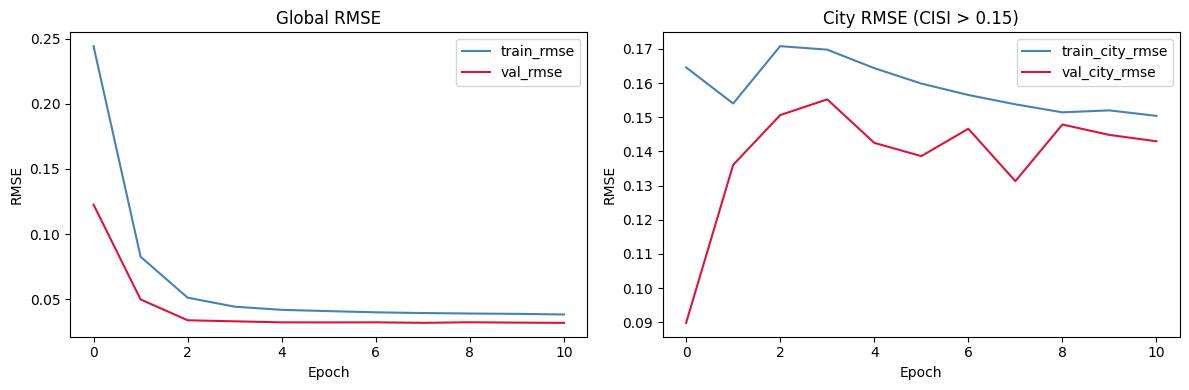

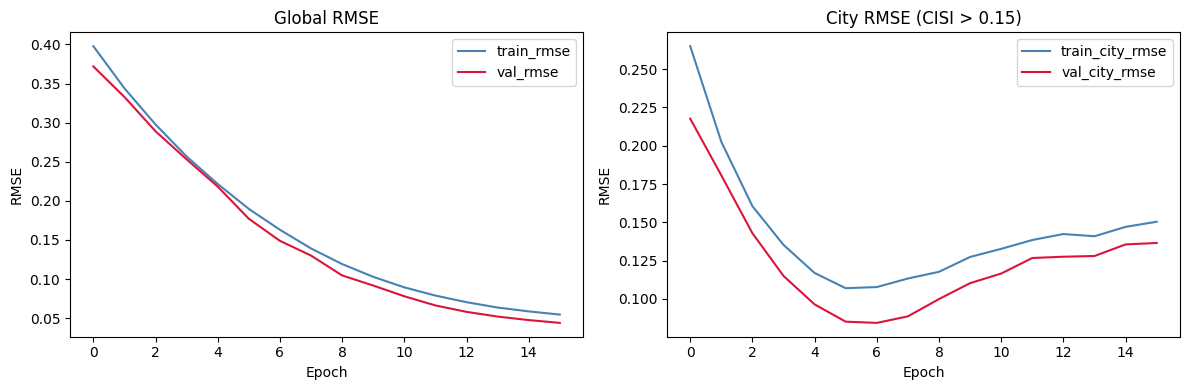

In [43]:
best_train_rmse = 999.0

# Load previous best if sweep was already partially run
if os.path.exists(BEST_MODEL_PATH):
    ckpt = torch.load(BEST_MODEL_PATH, map_location='cpu')
    best_train_rmse = ckpt.get('global_rmse', 999.0)
    print('Resuming -- current best global_rmse:', round(best_train_rmse, 4))

wandb.agent(sweep_id, function=train_sweep, count=50)  
print('Sweep complete. Best model saved to', BEST_MODEL_PATH)

# Debugging checks

In [44]:
# import torch
# import numpy as np

# print("=" * 70)
# print("CHECKING FIRST BATCH FROM DATALOADER")
# print("=" * 70)

# # Get one batch
# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     print(f"\nBatch {batch_idx}:")
#     print(f"  Batch size: {inputs.shape[0]}")
#     print(f"  Input shape: {inputs.shape}")  # Should be (batch, 9, 32, 32)
#     print(f"  Target shape: {targets.shape}")  # Should be (batch, 1)
    
#     # Check for NaN/Inf in inputs
#     print(f"\n  INPUT CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(inputs).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(inputs).any().item()}")
#     print(f"    Min: {inputs.min().item():.4f}")
#     print(f"    Max: {inputs.max().item():.4f}")
#     print(f"    Mean: {inputs.mean().item():.4f}")
    
#     # Check for NaN/Inf in targets
#     print(f"\n  TARGET CHECKS:")
#     print(f"    Contains NaN: {torch.isnan(targets).any().item()}")
#     print(f"    Contains Inf: {torch.isinf(targets).any().item()}")
#     print(f"    Min: {targets.min().item():.4f}")
#     print(f"    Max: {targets.max().item():.4f}")
#     print(f"    Mean: {targets.mean().item():.4f}")
    
#     # Check each channel individually
#     print(f"\n  PER-CHANNEL CHECKS:")
#     channel_names = ['GDP', 'Pop', 'LC_0', 'LC_1', 'LC_2', 'LC_3', 'LC_4', 'LC_5', 'LC_6']
#     for ch in range(9):
#         ch_data = inputs[:, ch, :, :]
#         has_nan = torch.isnan(ch_data).any().item()
#         has_inf = torch.isinf(ch_data).any().item()
#         print(f"    {channel_names[ch]:6s}: min={ch_data.min().item():7.2f}, "
#               f"max={ch_data.max().item():7.2f}, "
#               f"NaN={has_nan}, Inf={has_inf}")
    
#     # Only check first batch
#     break

# print("\n" + "=" * 70)

In [45]:
# print("=" * 70)
# print("TESTING FORWARD PASS")
# print("=" * 70)

# model.eval()  # Set to eval mode first
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# with torch.no_grad():
#     for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#         inputs = inputs.to(device)
#         targets = targets.to(device).view(-1, 1)
        
#         print(f"\nBatch {batch_idx}:")
#         print(f"  Input device: {inputs.device}")
#         print(f"  Input requires_grad: {inputs.requires_grad}")
        
#         # Forward pass
#         try:
#             outputs = model(inputs)
            
#             print(f"\n  OUTPUT CHECKS:")
#             print(f"    Output shape: {outputs.shape}")
#             print(f"    Contains NaN: {torch.isnan(outputs).any().item()}")
#             print(f"    Contains Inf: {torch.isinf(outputs).any().item()}")
#             print(f"    Min: {outputs.min().item():.4f}")
#             print(f"    Max: {outputs.max().item():.4f}")
#             print(f"    Mean: {outputs.mean().item():.4f}")
            
#             # Compute loss
#             loss = criterion(outputs, targets)
#             print(f"\n  LOSS:")
#             print(f"    Loss value: {loss.item():.4f}")
#             print(f"    Loss is NaN: {torch.isnan(loss).item()}")
#             print(f"    Loss is Inf: {torch.isinf(loss).item()}")
            
#         except Exception as e:
#             print(f"   ERROR during forward pass: {e}")
#             import traceback
#             traceback.print_exc()
        
#         # Only test first batch
#         break

# print("\n" + "=" * 70)

In [46]:
# print("=" * 70)
# print("DEBUGGING ONE TRAINING STEP")
# print("=" * 70)

# model.train()

# for batch_idx, (inputs, targets, coords) in enumerate(train_loader):
#     inputs = inputs.to(device)
#     targets = targets.to(device).view(-1, 1)
    
#     print(f"\n=== STEP {batch_idx} ===")
    
#     # Zero gradients
#     optimizer.zero_grad()
    
#     # Forward
#     print("1. Forward pass...")
#     outputs = model(inputs)
#     print(f"   Outputs: min={outputs.min().item():.4f}, max={outputs.max().item():.4f}, "
#           f"NaN={torch.isnan(outputs).any().item()}")
    
#     # Loss
#     print("2. Computing loss...")
#     loss = criterion(outputs, targets)
#     print(f"   Loss: {loss.item():.4f}, NaN={torch.isnan(loss).item()}")
    
#     if torch.isnan(loss):
#         print("    NaN DETECTED IN LOSS!")
#         print(f"   Sample outputs: {outputs[:5].squeeze()}")
#         print(f"   Sample targets: {targets[:5].squeeze()}")
#         break
    
#     # Backward
#     print("3. Backward pass...")
#     loss.backward()
    
#     # Check gradients
#     print("4. Checking gradients...")
#     total_norm = 0
#     max_grad = 0
#     nan_grads = False
    
#     for name, param in model.named_parameters():
#         if param.grad is not None:
#             grad_norm = param.grad.data.norm(2).item()
#             total_norm += grad_norm ** 2
#             max_grad = max(max_grad, param.grad.abs().max().item())
            
#             if torch.isnan(param.grad).any():
#                 print(f"    NaN gradient in {name}")
#                 nan_grads = True
    
#     total_norm = total_norm ** 0.5
#     print(f"   Total gradient norm: {total_norm:.4f}")
#     print(f"   Max gradient value: {max_grad:.4f}")
    
#     if nan_grads:
#         print("    NaN DETECTED IN GRADIENTS!")
#         break
    
#     if total_norm > 1000:
#         print(f"    WARNING: Very large gradients! (norm={total_norm:.2f})")
    
#     # Clip
#     print("5. Clipping gradients...")
#     torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
#     # Step
#     print("6. Optimizer step...")
#     optimizer.step()
    
#     print("    Step complete\n")
    
#     # Only do 3 steps
#     if batch_idx >= 2:
#         break

# print("\n" + "=" * 70)

In [47]:
# print("=" * 70)
# print("CHECKING MODEL WEIGHTS")
# print("=" * 70)

# print("\nModel parameters:")
# for name, param in model.named_parameters():
#     print(f"  {name:40s}: shape={str(list(param.shape)):20s} "
#           f"mean={param.data.mean().item():8.4f} "
#           f"std={param.data.std().item():8.4f} "
#           f"NaN={torch.isnan(param.data).any().item()}")

# print("\n" + "=" * 70)

In [48]:
# Check if 0.1° CISI file is correct
# with rasterio.open(cisi_path) as src:
#     cisi = src.read(1)
#     print(f"CISI shape: {cisi.shape}")
#     print(f"CISI range: [{np.nanmin(cisi):.4f}, {np.nanmax(cisi):.4f}]")
#     print(f"Valid pixels: {(~np.isnan(cisi)).sum():,}")
#     print(f"Non-zero CISI: {(cisi > 0).sum():,}")

# Check alignment with GDP
# with rasterio.open(gdp_path) as src:
#     gdp = src.read(1)
#     print(f"\nGDP shape: {gdp.shape}")
#     print(f"GDP valid: {(~np.isnan(gdp)).sum():,}")

# Check dataset
# print(f"\nDataset valid indices: {len(dataset.valid_indices):,}")

In [49]:
# import os
# from pathlib import Path

# Check current working directory
# print(f"Current directory: {os.getcwd()}")

# List files in current directory
# print("\nFiles in current directory:")
# for file in Path('.').glob('*.pth'):
#     print(f"  ✅ {file}")

# Also check common locations
# locations_to_check = [
#     '.',
#     './models',
#     '../',
#     str(Path.home() / 'Downloads'),
# ]

# print("\nSearching for .pth files...")
# for loc in locations_to_check:
#     if os.path.exists(loc):
#         pth_files = list(Path(loc).glob('**/*.pth'))
#         if pth_files:
#             print(f"\n📁 Found in {loc}:")
#             for f in pth_files:
#                 print(f"  ✅ {f}")

In [50]:
# print(f"Pred min: {predictions.min():.4f}")
# print(f"Pred max: {predictions.max():.4f}")
# print(f"Actual min: {actuals.min():.4f}")
# print(f"Actual max: {actuals.max():.4f}")

In [51]:
# import rasterio
# import numpy as np

# with rasterio.open(cisi_path) as src:
#     cisi_data = src.read(1)
#     print(f"CISI file max: {np.nanmax(cisi_data):.4f}")
#     print(f"CISI file 99th percentile: {np.percentile(cisi_data[~np.isnan(cisi_data)], 99):.4f}")